<a href="https://colab.research.google.com/github/matiasarmesto/businessanalytics/blob/main/Assignments/Scripts/advise_invest_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AdviseInvest

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/Scripts/advise_invest_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AdviseInvest Data Dictionary

Variable    |Description |Type    |Code
---- | ------- | ------ | -----
Answered       | Customer response |    Binary    |0: customer did not answer scheduled call; 1: customer answered scheduled call
Income       | Customer income in US dollars|	Numeric
Female       | Customer gender|	Binary	0: female; 1: male
Age	         | Age in years|	Numeric
Job          | Nature of job|	Categorical|	0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer
Num_dependents | Number of people for whom the customer provides maintenance|	Numeric
Rent	| Customer rents	|Binary	|0: no; 1: yes
Own_res	| Customer owns residence|	Binary|	0: no; 1: yes
New_car| Recent new car purchase	|Binary|	New car purchase in the last 3 months: 0: no, 1: yes
Chk_acct | Checking account status	|Categorical|	0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD
Sav_acct	| Average balance in savings account|	Categorical|	0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD
Num_accts	| Number of accounts owned by customer	|Numeric
Mobile	| Mobile phone	|Binary	|0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call
Product| Type of product purchased after conversation with sales rep	|Categorical|	0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan



### Load Libraries

In this class we will be using
- Pandas
- Scikitlearn
- Matplotlib


In [2]:
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier, export_graphviz # Import Decision Tree Classifier
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Initial Data Understanding

 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [4]:
#Import the data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Buss. Analytics/adviseinvest_historical_data.csv')

In [5]:
#View the datatypes
df.dtypes

,0
answered,int64
income,int64
female,object
age,int64
job,int64
num_dependents,int64
rent,int64
own_res,int64
new_car,float64
chk_acct,int64


In [6]:
#Describe the data
df.describe()

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


In [7]:
df.head()

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Remove any variables that are not relevant to our analysis (if they relate to activity after the answer).
- Clean up the data and put it in a new datafram named "df_clean"


In [8]:
#delete outliers
df_clean = df[df['income'] >= 0]
df_clean = df_clean[df_clean['num_accts'] <= 20]
df_clean = df_clean[df_clean['age'] <= 100]
df_clean.describe()

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000,29498.000000,29500.000000,29500.000000,29500.000000,29500.000000,29500.000000
mean,0.546644,33772.866102,34.769695,1.915458,1.141017,0.210441,0.681085,0.240762,1.468475,0.956475,2.345085,0.091119,1.535797
std,0.497828,29373.749731,11.355331,0.658184,0.348045,0.407629,0.466064,0.427553,1.234740,1.483952,1.200797,0.287783,1.625911
min,0.000000,2760.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,74.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,8.000000,1.000000,4.000000


In [9]:
#remove variables that are not helpful
df_clean = df_clean.drop(columns=['rent'])
df.info()
#dropped rent variable since it is redundant with own_res variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


In [10]:
#cleanup any missing or non-standardized data
df_clean.dropna(how='any')
df_clean.isnull().sum()

,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
own_res,0
new_car,2
chk_acct,0
sav_acct,0


In [11]:
#new_car still has missing values, will remove those
df_clean['new_car'].replace(["", " ", "unknown"], np.nan, inplace=False)
df_clean = df_clean.dropna(subset=['new_car'])
df_clean.isnull().sum()

,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
own_res,0
new_car,0
chk_acct,0
sav_acct,0


### 2.2: Standardize variables

 - Change "answered" to yes/no and make it categorical
 - Convert any variables that should be an integer into an integer

In [12]:
df_clean.loc[:, 'answered'] = df_clean.loc[:, 'answered'].replace({1: 'yes', 0: 'no'})
df_clean.loc[:, 'answered'] = pd.Categorical(df_clean.loc[:, 'answered'])

<ipython-input-12-48669c85e7c7>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['yes' 'no' 'yes' ... 'yes' 'yes' 'no']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[:, 'answered'] = df_clean.loc[:, 'answered'].replace({1: 'yes', 0: 'no'})


In [13]:
# Convert variables
# new_car variable converted to integer
df_clean.loc[:, 'new_car'] = df_clean.loc[:, 'new_car'].astype(int)
# female variable converted to integer
df_clean.loc[:, 'female'] = df_clean.loc[:, 'female'].map({'M': 1}).fillna(0).astype(int)

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [14]:
#Convert categorical variables
df_clean.loc[:, ['job', 'chk_acct', 'sav_acct', 'mobile', 'product', 'own_res', 'new_car', 'female']] = df_clean.loc[:, ['job', 'chk_acct', 'sav_acct', 'mobile', 'product', 'own_res', 'new_car', 'female']].astype('category')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29498 entries, 0 to 29503
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29498 non-null  object  
 1   income          29498 non-null  int64   
 2   female          29498 non-null  object  
 3   age             29498 non-null  int64   
 4   job             29498 non-null  int64   
 5   num_dependents  29498 non-null  int64   
 6   own_res         29498 non-null  int64   
 7   new_car         29498 non-null  category
 8   chk_acct        29498 non-null  int64   
 9   sav_acct        29498 non-null  int64   
 10  num_accts       29498 non-null  int64   
 11  mobile          29498 non-null  int64   
 12  product         29498 non-null  int64   
dtypes: category(1), int64(10), object(2)
memory usage: 3.0+ MB


<ipython-input-14-dbe0fcf9074e>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.0, 0.0, 1.0, 0.0, 1.0, ..., 1.0, 0.0, 0.0, 1.0, 0.0]
Length: 29498
Categories (2, float64): [0.0, 1.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[:, ['job', 'chk_acct', 'sav_acct', 'mobile', 'product', 'own_res', 'new_car', 'female']] = df_clean.loc[:, ['job', 'chk_acct', 'sav_acct', 'mobile', 'product', 'own_res', 'new_car', 'female']].astype('category')


# Step 3: Exploratory Data Analysis (EDA)
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

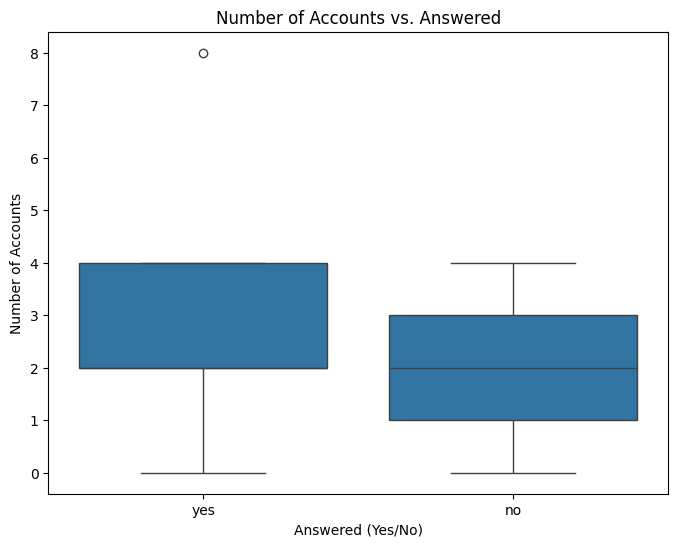

In [15]:
# Chart 1 - "answered vs number of acct"
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='num_accts', data=df_clean)
plt.title('Number of Accounts vs. Answered')
plt.xlabel('Answered (Yes/No)')
plt.ylabel('Number of Accounts')
plt.show()

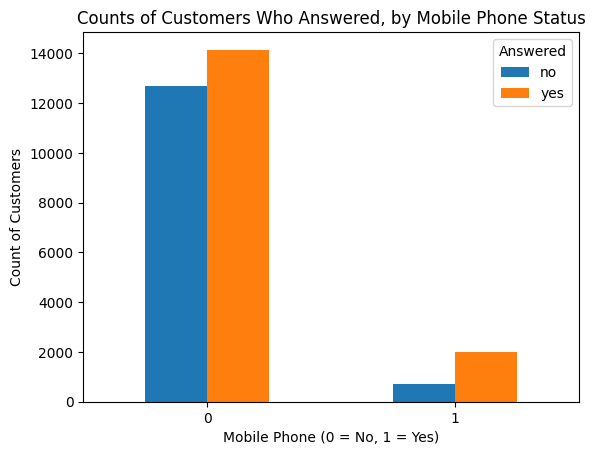

In [16]:
# Chart 2 --barplot of counts of customers who answered yes or no by mobile phone status
mobile_answered_counts = pd.crosstab(df_clean['mobile'], df_clean['answered'])

mobile_answered_counts.plot(kind='bar', stacked=False)
plt.title('Counts of Customers Who Answered, by Mobile Phone Status')
plt.xlabel('Mobile Phone (0 = No, 1 = Yes)')
plt.ylabel('Count of Customers')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Answered')
plt.show()

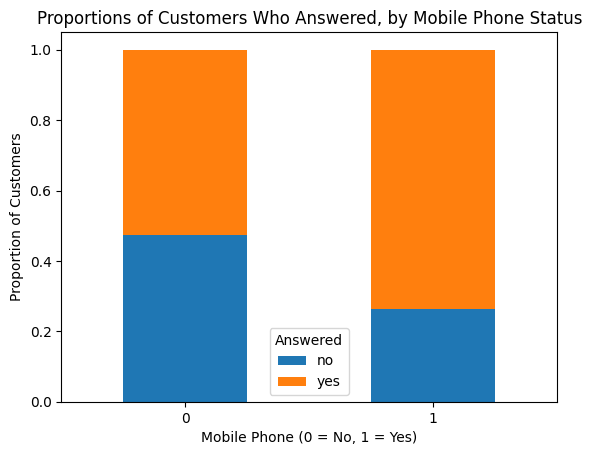

In [17]:
# Chart 3 --barplot showing the proportions of customers who answered ('yes' or 'no)
mobile_answered_props = mobile_answered_counts.div(mobile_answered_counts.sum(axis=1), axis=0)

mobile_answered_props.plot(kind='bar', stacked=True)
plt.title('Proportions of Customers Who Answered, by Mobile Phone Status')
plt.xlabel('Mobile Phone (0 = No, 1 = Yes)')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.legend(title='Answered')
plt.show()

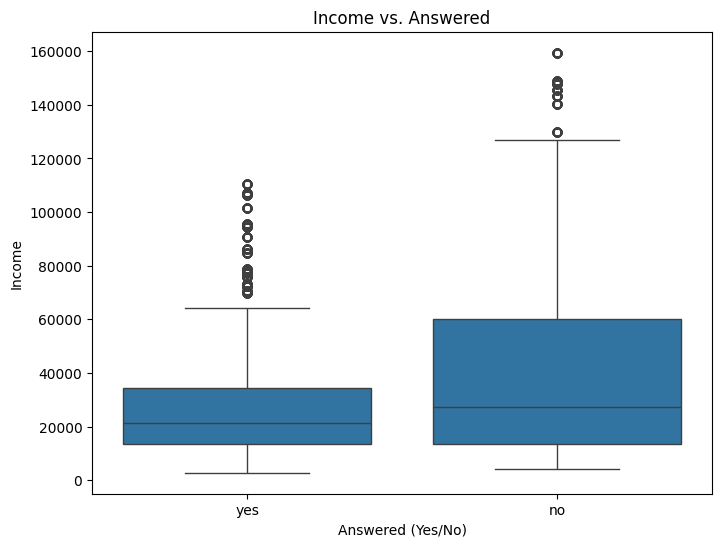

In [18]:
# Chart 4 --boxplot using income and answered
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Income vs. Answered')
plt.xlabel('Answered (Yes/No)')
plt.ylabel('Income')
plt.show()

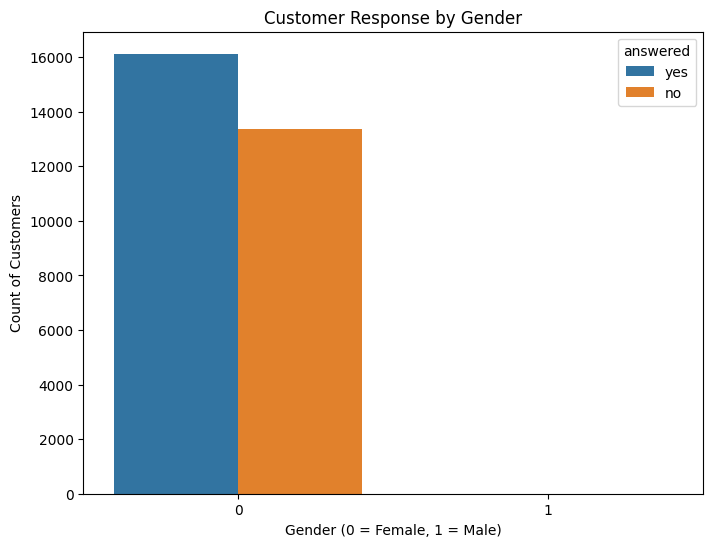

In [19]:
# Chart 5 - relationship between gender and answered
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.countplot(x='female', hue='answered', data=df_clean)
plt.title('Customer Response by Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count of Customers')
plt.show()

In [20]:
#I doublechecked the data and it looks like there really was only one male in all the customers...weird
num_males = df_clean['female'].eq(1).sum()

print(f"Number of male customers: {num_males}")

Number of male customers: 1


## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?

In [21]:
#dropping product for assignment 11
df_clean = df_clean.drop(columns=['product'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29498 entries, 0 to 29503
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29498 non-null  object  
 1   income          29498 non-null  int64   
 2   female          29498 non-null  object  
 3   age             29498 non-null  int64   
 4   job             29498 non-null  int64   
 5   num_dependents  29498 non-null  int64   
 6   own_res         29498 non-null  int64   
 7   new_car         29498 non-null  category
 8   chk_acct        29498 non-null  int64   
 9   sav_acct        29498 non-null  int64   
 10  num_accts       29498 non-null  int64   
 11  mobile          29498 non-null  int64   
dtypes: category(1), int64(9), object(2)
memory usage: 2.7+ MB


In [22]:
#get the default probability
#base probability of answering (yes)
base_probability_answering = df_clean['answered'].value_counts(normalize=True)['yes']
print(f"Base probability of a customer answering: {base_probability_answering}")

#base probability of not answering (no)
base_probability_not_answering = df_clean['answered'].value_counts(normalize=True)['no']
print(f"Base probability of a customer not answering: {base_probability_not_answering}")


Base probability of a customer answering: 0.546613329717269
Base probability of a customer not answering: 0.45338667028273105


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [23]:
# Split data into training and testing sets
x = df_clean.drop('answered', axis=1)
y = df_clean['answered']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) # 70% training and 30% test

### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [24]:
#create a tree
#decision tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=4)
#training decision tree classifer
clf = clf.fit(x_train,y_train)
#predicting response for test dataset
y_pred = clf.predict(x_test)

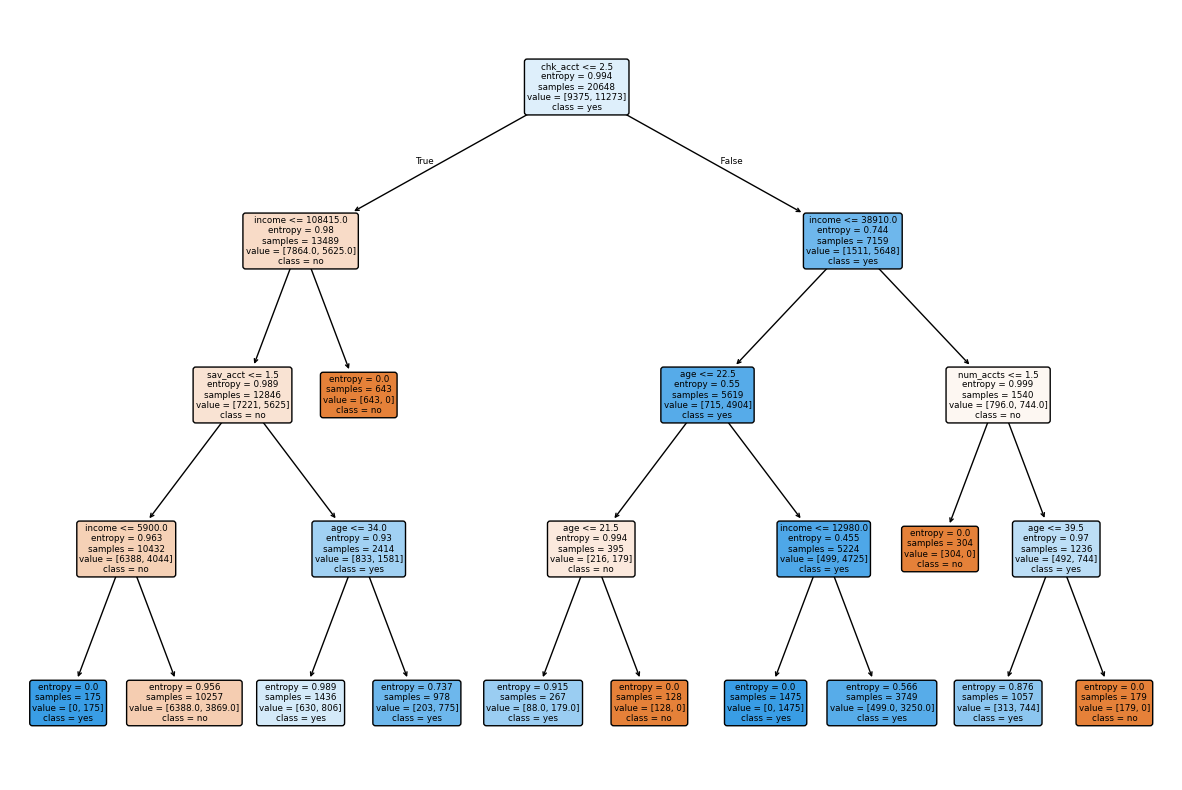

In [25]:
#display (visualize) the tree
plt.figure(figsize=(15, 10))
plot_tree(clf,
          feature_names=x_train.columns,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True)
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [26]:
#calculate the probability for your tree
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree: {accuracy}")

# Compare with base probability
print(f"Base probability of a customer answering: {base_probability_answering}")

if accuracy > base_probability_answering:
    print("The Decision Tree model has a higher accuracy than the base probability.")
else:
    print("The Decision Tree model does not have a higher accuracy than the base probability. Consider further model improvements.")

Accuracy of the Decision Tree: 0.7290395480225988
Base probability of a customer answering: 0.546613329717269
The Decision Tree model has a higher accuracy than the base probability.


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [27]:
#create a basic confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[3236  763]
 [1635 3216]]


Create a more visual, interpretable version of the matrix

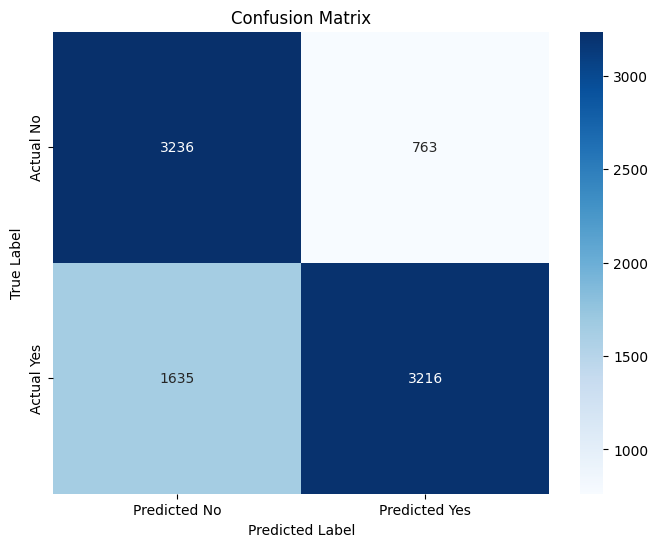

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Tree Model from Assignment 11

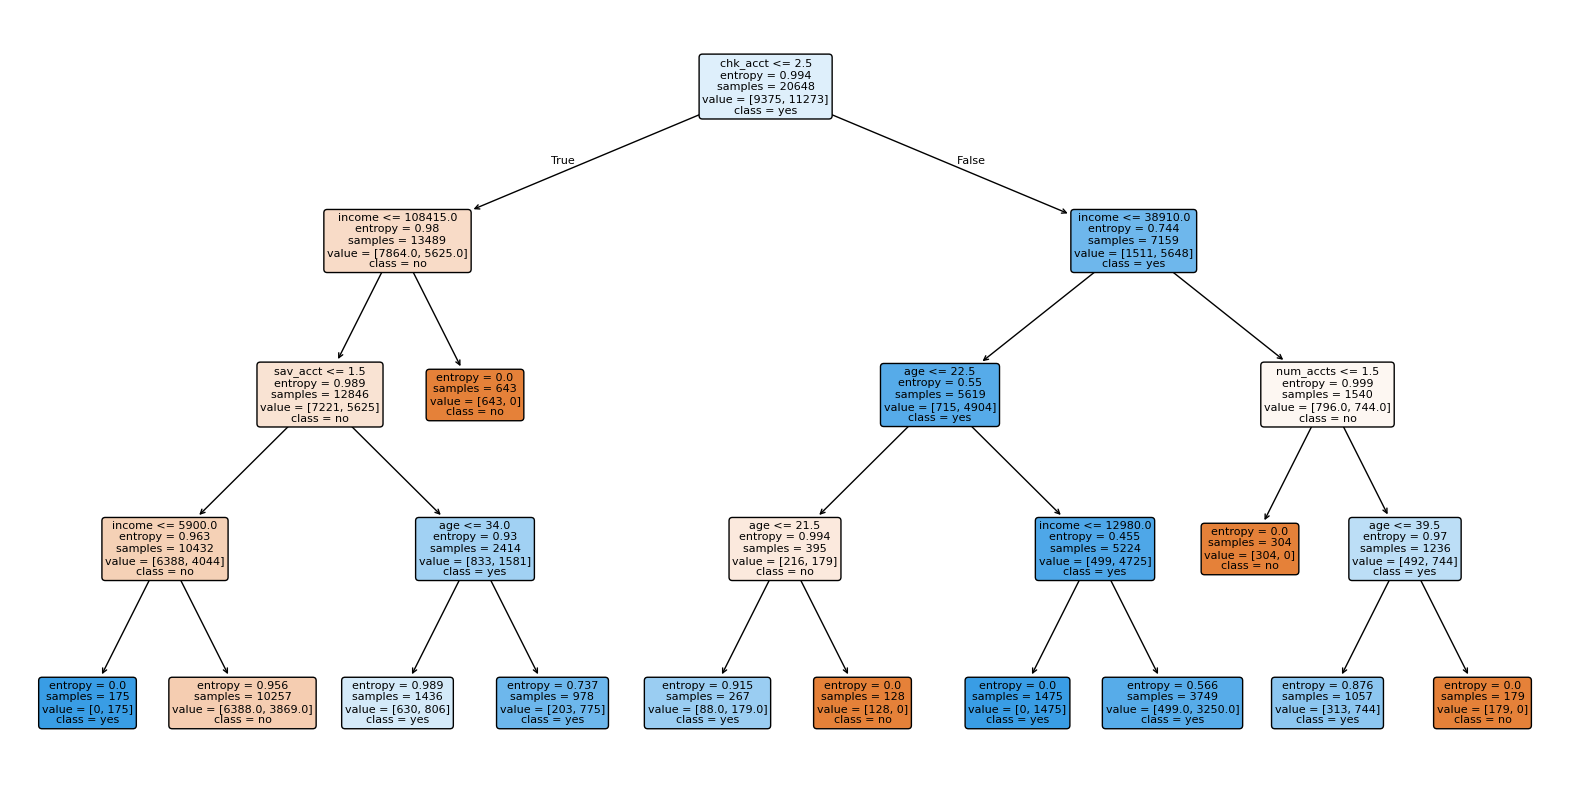

In [29]:
plt.figure(figsize=(20,10))
plot_tree(clf,
          feature_names=x_train.columns,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.show()

In [30]:
importances = clf.feature_importances_
feature_names = x_train.columns
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances.sort_values(by='importance', ascending=False, inplace=True)
print(feature_importances)

           feature  importance
7         chk_acct    0.374717
0           income    0.323273
2              age    0.160073
8         sav_acct    0.077565
9        num_accts    0.064372
1           female    0.000000
3              job    0.000000
6          new_car    0.000000
5          own_res    0.000000
4   num_dependents    0.000000
10          mobile    0.000000


# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [31]:
# Write a calcuation for the profit from your model
true_positives = conf_matrix[1, 1]  # Actual Yes, Predicted Yes
false_positives = conf_matrix[0, 1]  # Actual No, Predicted Yes
profit = (true_positives * 75) - (false_positives * 25)

print(f"Profit from the model: ${profit}")

Profit from the model: $222125


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [32]:
#Write a calculation for the overall profit without using the model (default)
total_customers = len(df_clean)
answered_customers = df_clean['answered'].value_counts()['yes']
not_answered_customers = total_customers - answered_customers

baseline_profit = (answered_customers * 75) - (not_answered_customers * 25)

print(f"Baseline profit (calling all customers): ${baseline_profit}")

Baseline profit (calling all customers): $874950


In [33]:
# Assuming y_test represents the actual answers for the test set
total_customers_test = len(y_test)
answered_customers_test = y_test.value_counts()['yes']
not_answered_customers_test = total_customers_test - answered_customers_test

baseline_profit_test = (answered_customers_test * 75) - (not_answered_customers_test * 25)

print(f"Baseline profit (test set): ${baseline_profit_test}")

Baseline profit (test set): $263850


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Continue to make changes until you find a set of hyperparameters that improves the accuracy compared to the initial model

In [34]:
# Create a new version of the tree with new parameters
new_clf = DecisionTreeClassifier(criterion="entropy", max_depth=5, min_samples_split=10, random_state=1)
new_clf = new_clf.fit(x_train, y_train)
new_y_pred = new_clf.predict(x_test)

In [35]:
# Calculate a new probability
new_accuracy = metrics.accuracy_score(y_test, new_y_pred)
print(f"New Accuracy of the Decision Tree: {new_accuracy}")
new_conf_matrix = confusion_matrix(y_test, new_y_pred)
print(new_conf_matrix)

New Accuracy of the Decision Tree: 0.7629378531073446
[[3478  521]
 [1577 3274]]


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable

In [36]:
#Import new customer data into a new data frame
new_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Buss. Analytics/adviseinvest_new_customer_data.csv')
# Drop columns not used in training
new_df = new_df.drop(columns=['customer_id', 'rent'], errors='ignore')

In [37]:
#Predict the number of customers who will be yes/no for the target variable
new_predictions = new_clf.predict(new_df)
predictions_df = pd.DataFrame({'Customer_ID': new_df.index, 'Predicted_Answer': new_predictions})
# Count the number of 'yes' and 'no' predictions
prediction_counts = predictions_df['Predicted_Answer'].value_counts()
# Print the prediction counts
print("Prediction Counts:")
print(prediction_counts)

Prediction Counts:
Predicted_Answer
no     562
yes    438
Name: count, dtype: int64


# Step 6: Plan for Deployment
### 6.1: Did we improve our profit using the model?  

In [38]:
# Assuming y_test represents the actual answers for the test set
total_customers_test = len(y_test)
answered_customers_test = y_test.value_counts()['yes']
not_answered_customers_test = total_customers_test - answered_customers_test

baseline_profit_test = (answered_customers_test * 75) - (not_answered_customers_test * 25)

print(f"Baseline profit (test set): ${baseline_profit_test}")

Baseline profit (test set): $263850


In [39]:
if profit > baseline_profit_test:
    print("The model profit is better than the baseline profit on the test set.")
else:
    print("The baseline profit is better than the model profit on the test set.")

The baseline profit is better than the model profit on the test set.


In [40]:
pdiff = baseline_profit_test - profit
print(f"The model profit is ${pdiff} less than the baseline profit on the test set.")

The model profit is $41725 less than the baseline profit on the test set.


Write your conclusion notes below:
>>
The model profit was $$222,125 while the baseline profit (on the test data) was $263,850. Using the model made the company lose $41,725. Meaning, no, the model did not improve the profit even though it had a higher accuracy score.

### 6.2: How should the model be deployed?

Write your recommendations below:
 >>
Although the accuracy is better in the model, there's some factors that could be taken into account. For example, the business problem that the customer wants solved is the underutilization of staff and unnecessary idling that could raise overhead costs. The model as is with .5 threshold would limit the wasted time of staff calling customers that do not answer, and therefore purchase the product. On the other hand, reducing the threshold to .3 raises the probability of both TP and FP, but yielded a higher profit than both the model (.5 thresh) and baseline at $$278,100. I think talking to the client and explaining the pros and cons of which model would be beneficial. In my own opinion, I would lower the threshold to .3 and use that model since it addresses both the unproductability and increase in profit. The client might care more about the idling time of employees and maybe reduce their working hours to cut overhead costs. It's important to introduce both solutions to the client so that they can make a decision prior to deploying a final model.


In [41]:
#assignment 13 step 3
#predict probabilities
probabilities = new_clf.predict_proba(new_df)[:, 1]  # Probability of 'yes'

#create a DataFrame with predicted probabilities and class labels
predictions_df = pd.DataFrame({
    'Customer_ID': new_df.index,
    'Predicted_Probability': probabilities,
    'Predicted_Class': ['yes' if prob >= 0.3 else 'no' for prob in probabilities]
})

#filter for customers with predicted class 'yes'
contact_list = predictions_df[predictions_df['Predicted_Class'] == 'yes']

#display the contact list
contact_list


,Customer_ID,Predicted_Probability,Predicted_Class
0,0,0.352417,yes
1,1,0.352417,yes
2,2,0.352417,yes
3,3,0.352417,yes
5,5,0.940637,yes
...,...,...,...
995,995,0.352417,yes
996,996,0.696562,yes
997,997,0.352417,yes
998,998,0.775790,yes


In [42]:
#predicting profit with a .3 threshold
#predict probabilities
probabilities = new_clf.predict_proba(x_test)[:, 1]  # Probability of 'yes'

#0.3 threshold
predictions_03 = ['yes' if prob >= 0.3 else 'no' for prob in probabilities]

#onfusion matrix
conf_matrix_03 = confusion_matrix(y_test, predictions_03)

#values from confusion matrix
true_positives_03 = conf_matrix_03[1, 1]
false_positives_03 = conf_matrix_03[0, 1]

#profit
profit_03 = (true_positives_03 * 75) - (false_positives_03 * 25)

#print profit
print(f"Profit with 0.3 threshold: ${profit_03}")

Profit with 0.3 threshold: $278100


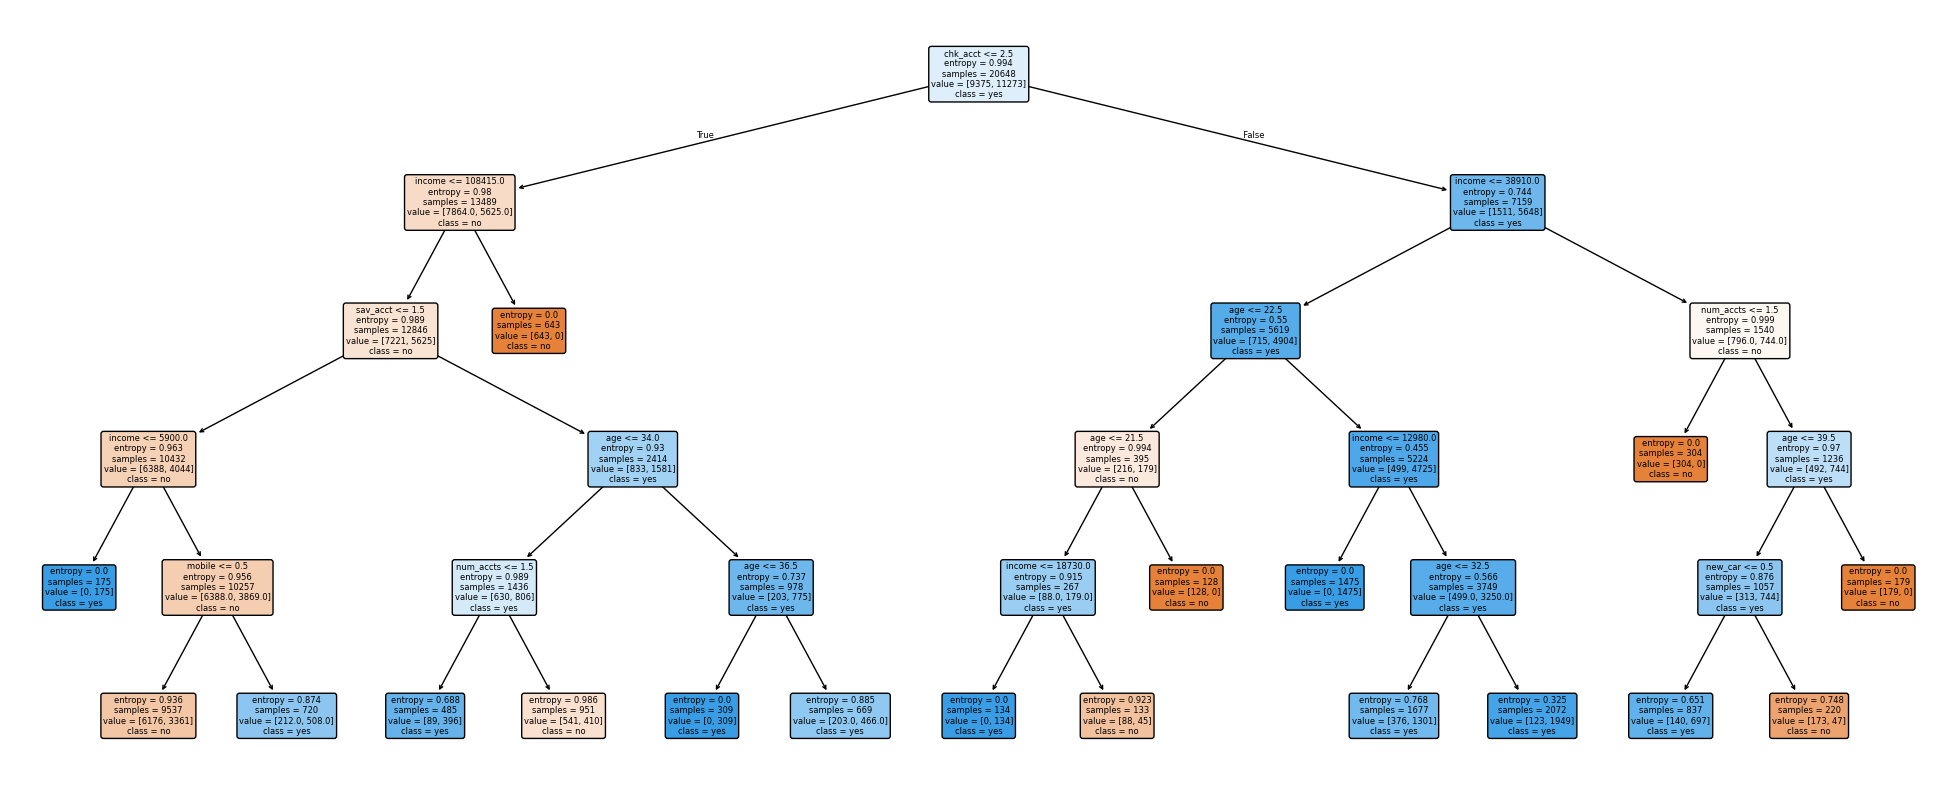

In [46]:
# prompt: show me the decision tree with the .3 threshold

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25,10))
plot_tree(new_clf,
          feature_names=x_train.columns,
          class_names=['no', 'yes'],
          filled=True,
          rounded=True,
          fontsize=6)
plt.show()
